# Huấn luyện YOLOv8n: Phát hiện Người, Lửa, Chó, Mèo

Notebook này kết hợp hai bộ dữ liệu từ Kaggle để tạo thành một bộ dataset YOLO hợp nhất.
Sử dụng Ultralytics YOLOv8 để huấn luyện, đánh giá mô hình chuyên nghiệp và tải model về máy tính.

## 1. Cài đặt thư viện và Thiết lập Môi trường

In [1]:
!pip install ultralytics -q

import os
import shutil
import glob
import yaml
import xml.etree.ElementTree as ET
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from IPython.display import FileLink

# Thiết lập thư mục làm việc
FIRE_DIR = "/kaggle/input/datasets/paulisca8/fire-person-yolo-format/max_dataset"
DOGCAT_DIR = "/kaggle/input/datasets/andrewmvd/dog-and-cat-detection"
WORK_DIR = "/kaggle/working/dataset"
RUNS_DIR = "/kaggle/working/runs"

os.makedirs(WORK_DIR, exist_ok=True)
for split in ['train', 'val']:
    os.makedirs(f"{WORK_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{WORK_DIR}/labels/{split}", exist_ok=True)

print("✅ Môi trường đã sẵn sàng.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.6 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Môi trường đã sẵn sàng.


## 2. Tiền xử lý Dữ liệu (Người & Lửa)
Bộ dữ liệu này đã định dạng chuẩn YOLO, chỉ cần sao chép và thiết lập Class ID cơ sở.

In [2]:
# Đọc cấu trúc class của dataset Fire-Person
yaml_path = f"{FIRE_DIR}/data.yaml"
if os.path.exists(yaml_path):
    with open(yaml_path) as f:
        names = yaml.safe_load(f)['names']
    names = names if isinstance(names, dict) else {i: n for i, n in enumerate(names)}
else:
    names = {0: 'fire', 1: 'person'}  # Dự phòng nếu thiếu data.yaml

# Sao chép Fire-Person dataset
for sp_in, sp_out in [('train', 'train'), ('valid', 'val')]:
    src_img_dir = f"{FIRE_DIR}/{sp_in}/images"
    if os.path.exists(src_img_dir):
        os.system(f"cp -r {src_img_dir}/* {WORK_DIR}/images/{sp_out}/")
        os.system(f"cp -r {FIRE_DIR}/{sp_in}/labels/* {WORK_DIR}/labels/{sp_out}/")

print(f"✅ Đã copy xong dataset Lửa/Người. Các class cơ sở: {names}")

✅ Đã copy xong dataset Lửa/Người. Các class cơ sở: {0: 'fire', 1: 'person'}


## 3. Tiền xử lý Dữ liệu (Chó & Mèo)
Chuyển XML (PASCAL VOC) sang Text (YOLO) và bổ sung vào cuối danh sách Class ID.

In [3]:
dog_id, cat_id = len(names), len(names) + 1
names[dog_id], names[cat_id] = 'dog', 'cat'

imgs = glob.glob(f"{DOGCAT_DIR}/images/*.png")
for i, img_path in enumerate(imgs):
    split = 'train' if i < int(len(imgs) * 0.8) else 'val'
    xml_path = img_path.replace('images', 'annotations').replace('.png', '.xml')
    if not os.path.exists(xml_path): continue
    
    tree = ET.parse(xml_path)
    w, h = Image.open(img_path).size
    labels = []
    for obj in tree.getroot().findall('object'):
        cls = obj.find('name').text.lower()
        if cls not in ['dog', 'cat']: continue
        cid = dog_id if cls == 'dog' else cat_id
        box = obj.find('bndbox')
        xmin, ymin, xmax, ymax = [float(box.find(x).text) for x in ['xmin', 'ymin', 'xmax', 'ymax']]
        
        # YOLO format: class_id x_center y_center width height (Normalized 0.0 -> 1.0)
        x_c, y_c = (xmin+xmax)/2/w, (ymin+ymax)/2/h
        bw, bh = (xmax-xmin)/w, (ymax-ymin)/h
        labels.append(f"{cid} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}")
        
    if labels:
        shutil.copy(img_path, f"{WORK_DIR}/images/{split}/")
        with open(f"{WORK_DIR}/labels/{split}/" + os.path.basename(img_path).replace('.png', '.txt'), 'w') as f:
            f.write("\n".join(labels))

print(f"✅ Đã chuyển đổi vả gộp dataset Chó/Mèo. Danh sách Class mới: {names}")

✅ Đã chuyển đổi vả gộp dataset Chó/Mèo. Danh sách Class mới: {0: 'fire', 1: 'person', 2: 'dog', 3: 'cat'}


## 4. Khởi tạo Cấu hình & Bắt đầu Huấn luyện YOLOv8

In [4]:
# Tạo file data.yaml kết hợp
data_yaml = {
    'path': WORK_DIR,
    'train': 'images/train',
    'val': 'images/val',
    'names': names
}
yaml_path = f"{WORK_DIR}/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

# Khởi tạo mô hình bản Nano (tối ưu hóa cho tốc độ và nhẹ)
model = YOLO('yolov8n.pt')

# Huấn luyện mô hình
# (Lưu ý: Mặc định project được lưu trong /kaggle/working/runs/detect/train)
results = model.train(
    data=yaml_path, 
    epochs=50, 
    imgsz=640, 
    batch=32, 
    device=0,
    plots=True  # Bật auto-generate các đồ thị phân tích
)
print("✅ Hoàn tất quá trình Huấn luyện.")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

## 5. Phân tích Các Biểu đồ Thống kê (Kết quả Train/Val)
Sau khi train, Ultralytics YOLO tự động sinh các biểu đồ về Loss, mAP, Precision, Recall.

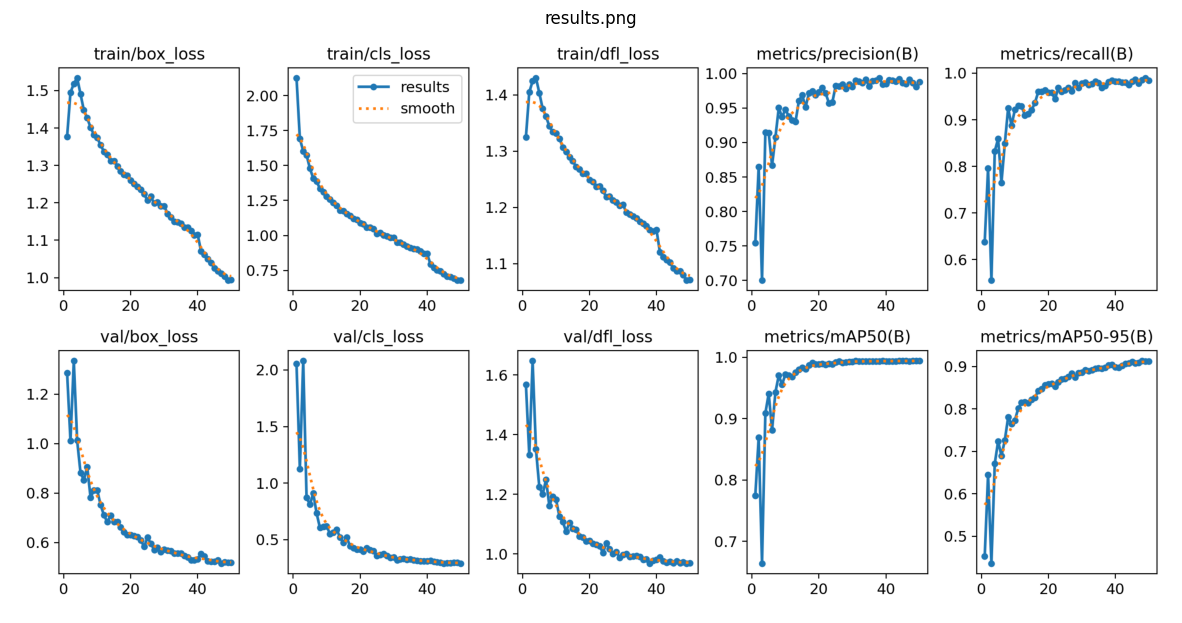

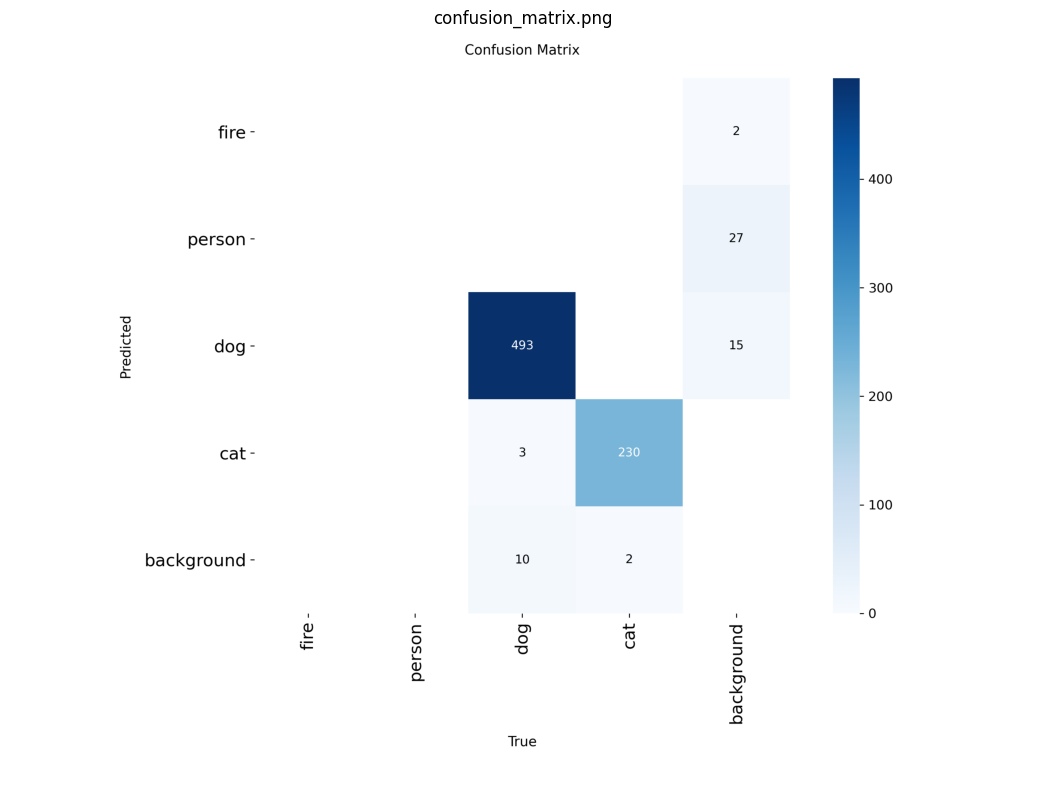

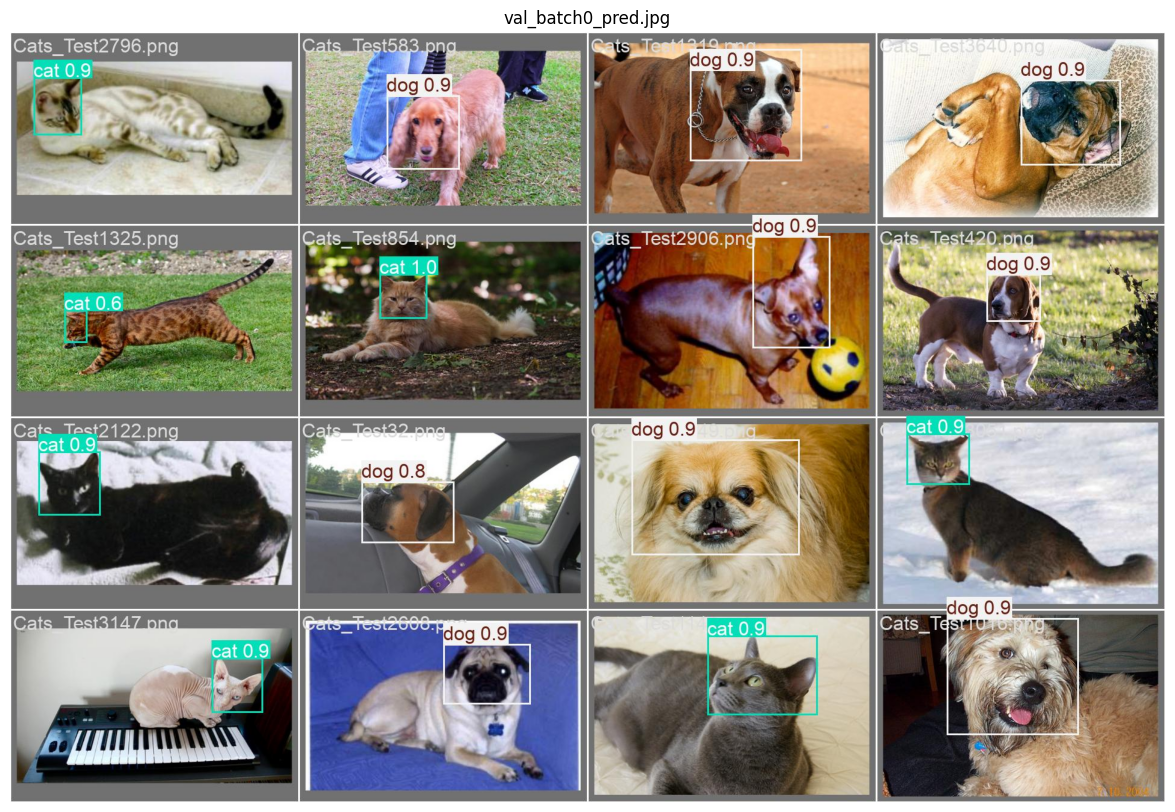

In [5]:
run_dir = results.save_dir  # Thư mục lưu kết quả hiện tại (thường là runs/detect/train)

plots_to_show = [
    "results.png",             # Biểu đồ Loss & mAP qua các epochs
    "confusion_matrix.png",    # Ma trận nhầm lẫn (Confusion Matrix)
    "val_batch0_pred.jpg"      # Ví dụ các nhãn dự đoán trên tập Valid
]

for plot_name in plots_to_show:
    plot_path = os.path.join(run_dir, plot_name)
    if os.path.exists(plot_path):
        img = cv2.imread(plot_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(15, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(plot_name)
        plt.show()
    else:
        print(f"⚠️ Không tìm thấy biểu đồ: {plot_name}")

## 6. Chạy Test Thử Nghiệm Mô hình Trực tiếp (Inference)
Test trực tiếp mô hình vừa huấn luyện xong trên một vài hình ảnh ngẫu nhiên từ tập validation.


0: 640x640 1 dog, 14.7ms
1: 640x640 1 cat, 14.7ms
2: 640x640 1 cat, 14.7ms
Speed: 2.6ms preprocess, 14.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


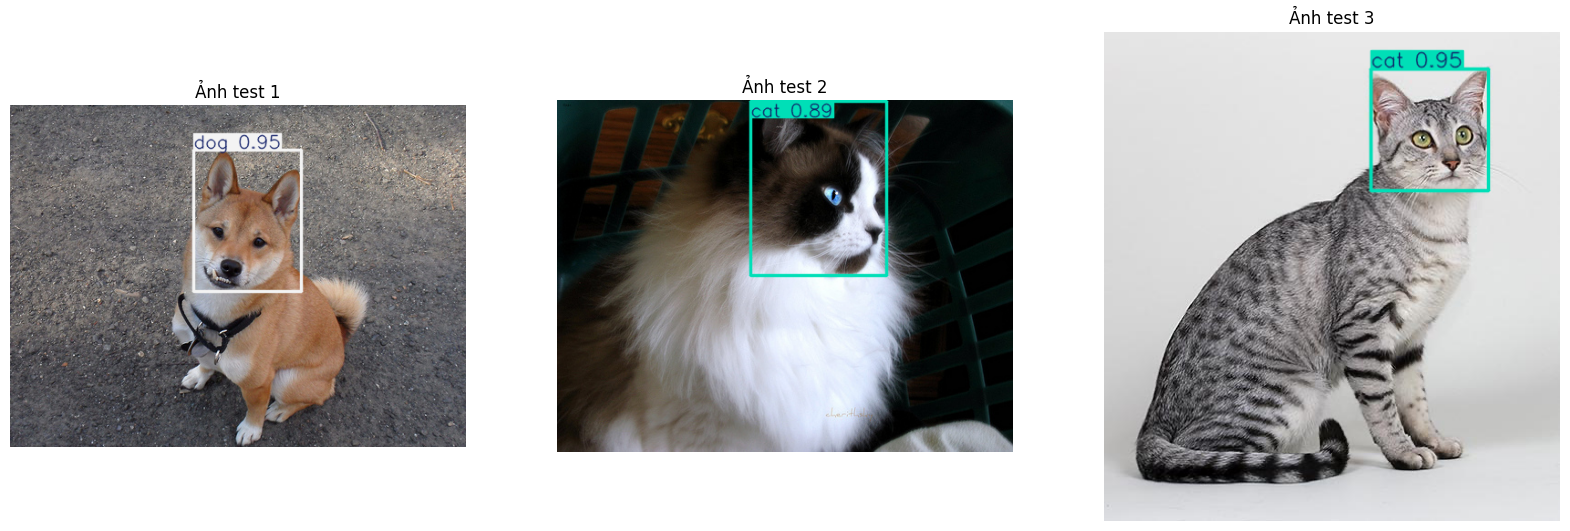

In [6]:
import random

best_weight = os.path.join(run_dir, 'weights', 'best.pt')
if os.path.exists(best_weight):
    best_model = YOLO(best_weight)
    
    # Lấy 3 ảnh validation bất kỳ
    val_images = glob.glob(f"{WORK_DIR}/images/val/*.png") + glob.glob(f"{WORK_DIR}/images/val/*.jpg")
    test_imgs = random.sample(val_images, min(3, len(val_images)))
    
    # Chạy Predict
    infer_results = best_model.predict(test_imgs, conf=0.5)
    
    # Vẽ kết quả
    plt.figure(figsize=(20, 10))
    for i, res in enumerate(infer_results):
        res_plotted = res.plot()
        # OpenCV dùng hệ màu BGR, matplotlib dùng RGB
        res_plotted_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 3, i + 1)
        plt.imshow(res_plotted_rgb)
        plt.axis('off')
        plt.title(f"Ảnh test {i+1}")
    plt.show()
else:
    print("⚠️ Chưa bắt đầu có file weight, hãy chạy Cell Huấn luyện trước!")

## 7. Lưu Model và Dọn dẹp dữ liệu (Tránh DATA LEAK Kaggle)
Sao lưu file trọng số tốt nhất (`best.pt`) và xóa thư mục dữ liệu làm việc để giữ Output của Kaggle được an toàn, sạch sẽ, không bị lộ ra ngoài sau khi Save phiên.

In [7]:
OUTPUT_MODEL = "/kaggle/working/best_model_yolov8.pt"

if os.path.exists(best_weight):
    # 1. Copy file model ra thư mục ngoài cùng của output để có thể dễ tải xuống nhất
    shutil.copy(best_weight, OUTPUT_MODEL)
    print(f"✅ Đã trích xuất mô hình hoàn chỉnh tại: {OUTPUT_MODEL}")
    
    # 2. Tạo link Click-to-Download trực tiếp nằm ở Output của Cell
    display(FileLink(r'best_model_yolov8.pt'))
    

✅ Đã trích xuất mô hình hoàn chỉnh tại: /kaggle/working/best_model_yolov8.pt


/kaggle/working/best_model_yolov8.pt

🗑️ Đã thu dọn hoàn toàn thư mục Dataset custom tự tạo và thư mục Runs trung gian. (Safe From Data Leak!)
